# Example 4: Regulated-Basin Streamflow Forecasting (Experiment 4)

Mirrors the paper's Experiment 4: daily streamflow forecasting at dam-regulated basins, comparing
forecasts with and without observed reservoir outflow supplied as an additional covariate --
demonstrating HydroORBIT's ability to accept a previously unseen input variable at inference time
with no retraining.

**Case study**: basin `10312150` (Carson River below Lahontan Reservoir, NV; dam 514 = Lahontan) --
selected as the highest-median-NSE basin with full lead-time coverage in the paper's Experiment 4
(`dam_outflow` scenario) evaluation. This notebook runs 30 forecast cycles spread across the 2018
evaluation year and reports NSE **at each lead time**, pooled across those 30 cycles, for both the
with- and without-outflow configurations.

Data: `data/exp4_regulated_basin/10312150_dam514.csv` -- daily forcing, streamflow, and reservoir
outflow (`DamOutflow`, from ResOpsUS), 2016-01-01 to 2018-12-31; 2016-2017 provides trailing context
for origins issued during 2018.


In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

REPO_ROOT = Path.cwd().parent
sys.path.insert(0, str(REPO_ROOT))

from src.pipeline import HydroORBITPipeline

WEIGHTS_DIR = REPO_ROOT / "weights"
pipe = HydroORBITPipeline.from_pretrained(str(WEIGHTS_DIR))
print("Loaded HydroORBIT on device:", pipe.device)

FORCING_COLS = ["Tair", "Qair", "PSurf", "Wind_E", "Wind_N", "LWdown",
                "CRainf_frac", "CAPE", "PotEvap", "Rainf", "SWdown"]

def nse(obs, sim, min_samples=24):
    """Nash-Sutcliffe efficiency, pooled across whatever (obs, sim) pairs are given.
    Returns NaN below min_samples or when the observed variance is degenerate
    (near-constant obs), matching the guard used for the paper's own metrics."""
    obs = np.asarray(obs, dtype=float)
    sim = np.asarray(sim, dtype=float)
    mask = np.isfinite(obs) & np.isfinite(sim)
    obs, sim = obs[mask], sim[mask]
    if len(obs) < min_samples:
        return np.nan
    den = np.sum((obs - obs.mean()) ** 2)
    scale = max(abs(obs.mean()), 1.0)
    if den <= (1e-10 * scale) ** 2 * len(obs):
        return np.nan
    return 1.0 - np.sum((sim - obs) ** 2) / den


def origins_for_eval_year(index, year, context_len, horizon):
    """Positions in `index` that fall within `year` and have enough trailing
    context (context_len) and enough remaining data (horizon) around them."""
    positions = np.where(index.year == year)[0]
    positions = positions[(positions >= context_len) & (positions + horizon <= len(index))]
    return positions


Loaded HydroORBIT on device: mps


In [2]:
BASIN_FILE = "10312150_dam514"
CONTEXT_LEN = 730         # 2 years of daily context
HORIZON = 10                 # 10-day forecast, the paper's longest daily lead time for this experiment
N_ORIGINS = 40                 # forecast cycles spread across the 2018 evaluation year
EVAL_YEAR = 2018

df = pd.read_csv(f"data/exp4_regulated_basin/{BASIN_FILE}.csv", index_col="datetime", parse_dates=True)
print(df.shape, df.index.min(), "->", df.index.max())
df.tail()


(1096, 13) 2016-01-01 00:00:00 -> 2018-12-31 00:00:00


,Tair,Qair,PSurf,Wind_E,Wind_N,LWdown,CRainf_frac,CAPE,PotEvap,Rainf,SWdown,Streamflow,DamOutflow
datetime,,,,,,,,,,,,,
2018-12-27,-4.265304,0.002495,82376.242746,0.509077,-2.774375,203.734966,0.0,4.139048,0.025439,0.00001,93.268082,0.001820,0.095
2018-12-28,-6.165660,0.001984,82646.933942,-3.708080,-3.642158,206.323582,0.0,1.395381,0.049495,0.00000,106.642815,0.001819,0.095
2018-12-29,-5.596703,0.001845,83113.729608,-1.222485,-0.309643,197.641171,0.0,0.000000,0.035018,0.00000,103.117005,0.001828,0.095
2018-12-30,0.937361,0.002944,82735.923805,2.843140,-1.018304,221.920903,0.0,0.000000,0.035408,0.00000,104.744165,0.001836,0.095
2018-12-31,-3.271524,0.002377,82098.115072,-1.994048,-3.704256,211.806810,0.0,1.473018,0.053349,0.00000,105.552309,0.001844,0.096


In [3]:
positions = origins_for_eval_year(df.index, EVAL_YEAR, CONTEXT_LEN, HORIZON)
origins = positions[np.linspace(0, len(positions) - 1, N_ORIGINS).astype(int)]
COV_COLS = FORCING_COLS + ["DamOutflow"]

runs = []
for origin in origins:
    ctx_slice = df.iloc[origin - CONTEXT_LEN:origin]
    fut_slice = df.iloc[origin:origin + HORIZON]
    target = ctx_slice["Streamflow"].to_numpy(np.float32)
    observed_future = fut_slice["Streamflow"].to_numpy(np.float32)

    # Without reservoir information: only meteorological forcing is known, historically and in the future.
    forcing_noout = ctx_slice[FORCING_COLS].to_numpy(np.float32)
    future_forcing_noout = fut_slice[FORCING_COLS].to_numpy(np.float32)
    out_noout = pipe.predict(target, forcing=forcing_noout, future_forcing=future_forcing_noout,
                              prediction_length=HORIZON)

    # With reservoir information: DamOutflow is added as an extra known covariate (historical + future).
    forcing_out = ctx_slice[COV_COLS].to_numpy(np.float32)
    future_forcing_out = fut_slice[COV_COLS].to_numpy(np.float32)
    out_out = pipe.predict(target, forcing=forcing_out, future_forcing=future_forcing_out,
                            prediction_length=HORIZON)

    runs.append({
        "issue_time": df.index[origin], "observed": observed_future,
        "median_noout": out_noout.median[0].numpy(), "median_out": out_out.median[0].numpy(),
    })
print(f"Ran {len(runs)} forecast cycles across {EVAL_YEAR}.")


Ran 40 forecast cycles across 2018.


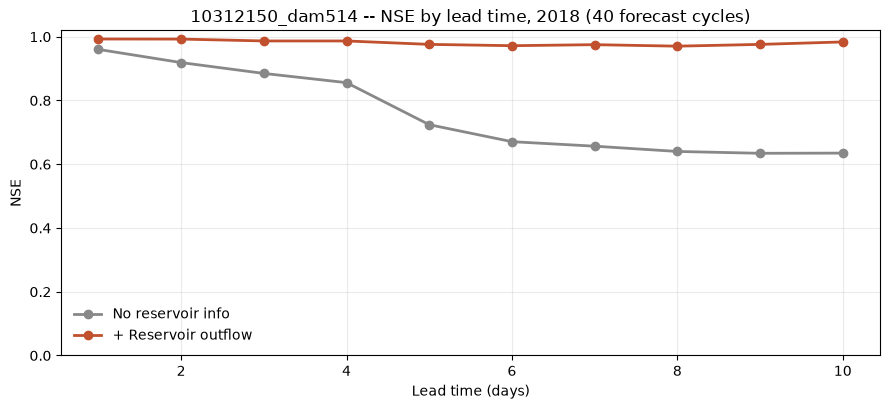

Median NSE without outflow: 0.697   with outflow: 0.980


In [4]:
obs_stack = np.stack([r["observed"] for r in runs])
sim_noout_stack = np.stack([r["median_noout"] for r in runs])
sim_out_stack = np.stack([r["median_out"] for r in runs])
lead_d = np.arange(1, HORIZON + 1)
nse_noout = np.array([nse(obs_stack[:, h], sim_noout_stack[:, h]) for h in range(HORIZON)])
nse_out = np.array([nse(obs_stack[:, h], sim_out_stack[:, h]) for h in range(HORIZON)])

fig, ax = plt.subplots(figsize=(9, 4.2))
ax.plot(lead_d, nse_noout, color="#888888", linewidth=2.0, marker="o", label="No reservoir info")
ax.plot(lead_d, nse_out, color="#C1502E", linewidth=2.0, marker="o", label="+ Reservoir outflow")
ax.set_ylim(0, 1.02)
ax.set_xlabel("Lead time (days)")
ax.set_ylabel("NSE")
ax.set_title(f"{BASIN_FILE} -- NSE by lead time, {EVAL_YEAR} ({N_ORIGINS} forecast cycles)")
ax.legend(frameon=False)
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()
print(f"Median NSE without outflow: {np.nanmedian(nse_noout):.3f}   with outflow: {np.nanmedian(nse_out):.3f}")


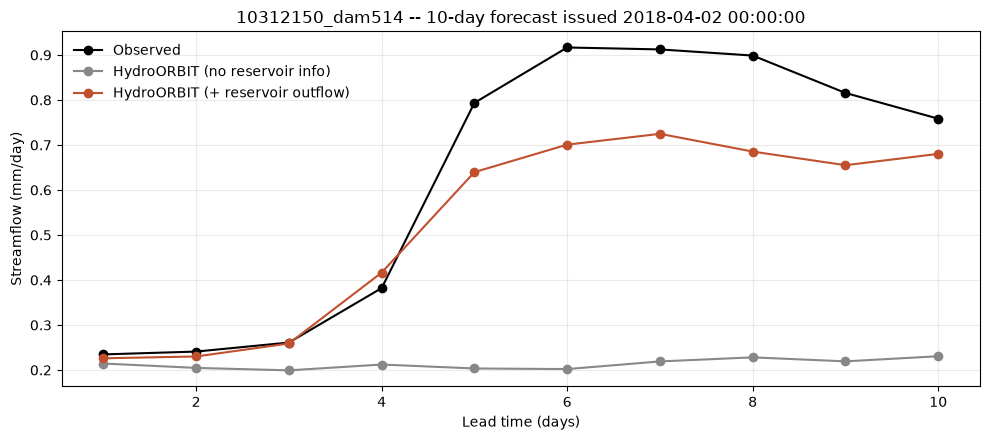

In [5]:
best = max(runs, key=lambda r: np.nanstd(r["observed"]))

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(lead_d, best["observed"], color="black", marker="o", linewidth=1.5, label="Observed")
ax.plot(lead_d, best["median_noout"], color="#888888", marker="o", linewidth=1.5, label="HydroORBIT (no reservoir info)")
ax.plot(lead_d, best["median_out"], color="#C1502E", marker="o", linewidth=1.5, label="HydroORBIT (+ reservoir outflow)")
ax.set_xlabel("Lead time (days)")
ax.set_ylabel("Streamflow (mm/day)")
ax.set_title(f"{BASIN_FILE} -- 10-day forecast issued {best['issue_time']}")
ax.legend(frameon=False)
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()
